##### wgi_cc   # Control of Corruption
##### wgi_ge   # Government Effectiveness
##### wgi_pv   # Political Stability
##### wgi_rl   # Rule of Law
##### wgi_rq   # Regulatory Quality
#####wgi_va   # Voice and Accountability

In [1]:
!pip install -q scikit-learn xgboost shap
!pip install -q tqdm

In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import shap
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm



In [3]:
projectDf = pd.read_excel('/content/IEG_ICRR_PPAR_Ratings_2025-09-03.xlsx')
riskDf = pd.read_excel('/content/country risk classification.xlsx')

In [4]:
# WGI Percentile 파일 불러오기
wgi = pd.read_csv("WB_WGI_r.csv")

In [5]:
wgi.head()

,REF_AREA,REF_AREA_LABEL,INDICATOR,INDICATOR_LABEL,UNIT_MEASURE,TIME_PERIOD,OBS_VALUE
0,ABW,Aruba,WB_WGI_CC_EST,Control of Corruption: Estimate,SCORE,1996,NaN
1,AFG,Afghanistan,WB_WGI_CC_EST,Control of Corruption: Estimate,SCORE,1996,-1.291705
2,AGO,Angola,WB_WGI_CC_EST,Control of Corruption: Estimate,SCORE,1996,-1.167702
3,AIA,Anguilla,WB_WGI_CC_EST,Control of Corruption: Estimate,SCORE,1996,NaN
4,ALB,Albania,WB_WGI_CC_EST,Control of Corruption: Estimate,SCORE,1996,-0.893903


In [6]:
# (1) Estimate 항목만 필터
wgi_est = wgi[wgi["INDICATOR_LABEL"].str.endswith("Estimate")].copy()

# (2) 필요한 컬럼만 추출
wgi_est = wgi_est[["REF_AREA", "TIME_PERIOD", "INDICATOR_LABEL", "OBS_VALUE"]]

# (3) 가로 피벗
wgi_wide = (
    wgi_est.pivot_table(
        index=["REF_AREA", "TIME_PERIOD"],
        columns="INDICATOR_LABEL",
        values="OBS_VALUE"
    )
    .reset_index()
)

# (4) 컬럼명 간결하게 정리
rename_map = {
    "Control of Corruption: Estimate": "wgi_cc",
    "Government Effectiveness: Estimate": "wgi_ge",
    "Political Stability and Absence of Violence/Terrorism: Estimate": "wgi_pv",
    "Rule of Law: Estimate": "wgi_rl",
    "Regulatory Quality: Estimate": "wgi_rq",
    "Voice and Accountability: Estimate": "wgi_va"
}
wgi_wide = wgi_wide.rename(columns=rename_map)
wgi_wide = wgi_wide.rename(columns={"REF_AREA": "iso3c", "TIME_PERIOD": "year"})

# (5) 정리 및 확인
wgi_clean = wgi_wide[["iso3c","year","wgi_cc","wgi_ge","wgi_pv","wgi_rl","wgi_rq","wgi_va"]].drop_duplicates()
print("Cleaned WGI shape:", wgi_clean.shape)
wgi_clean.head()

Cleaned WGI shape: (5246, 8)


INDICATOR_LABEL,iso3c,year,wgi_cc,wgi_ge,wgi_pv,wgi_rl,wgi_rq,wgi_va
0,ABW,2004,1.165965,1.281389,0.993218,0.915527,0.762954,0.737521
1,ABW,2005,1.269663,1.287598,1.376416,0.847438,0.864074,1.153230
2,ABW,2006,1.251313,1.279818,1.303461,0.810431,0.855287,1.017273
3,ABW,2007,1.261871,1.246601,1.286569,0.826464,0.877206,0.972129
4,ABW,2008,1.276775,1.270925,1.316396,0.847226,0.894702,0.967198


In [7]:
wgi_est = wgi[wgi["INDICATOR_LABEL"].str.endswith("Estimate")].copy()
wgi_est = wgi_est[["REF_AREA", "REF_AREA_LABEL", "TIME_PERIOD", "INDICATOR_LABEL", "OBS_VALUE"]]

wgi_wide = (
    wgi_est.pivot_table(
        index=["REF_AREA", "REF_AREA_LABEL", "TIME_PERIOD"],
        columns="INDICATOR_LABEL",
        values="OBS_VALUE"
    )
    .reset_index()
)

rename_map = {
    "Control of Corruption: Estimate": "wgi_cc",
    "Government Effectiveness: Estimate": "wgi_ge",
    "Political Stability and Absence of Violence/Terrorism: Estimate": "wgi_pv",
    "Rule of Law: Estimate": "wgi_rl",
    "Regulatory Quality: Estimate": "wgi_rq",
    "Voice and Accountability: Estimate": "wgi_va"
}

wgi_clean = (
    wgi_wide.rename(columns=rename_map)
    .rename(columns={"REF_AREA": "iso3c", "REF_AREA_LABEL": "Country", "TIME_PERIOD": "year"})
    [["iso3c","Country","year","wgi_cc","wgi_ge","wgi_pv","wgi_rl","wgi_rq","wgi_va"]]
)

In [8]:
wgi_clean.head()

INDICATOR_LABEL,iso3c,Country,year,wgi_cc,wgi_ge,wgi_pv,wgi_rl,wgi_rq,wgi_va
0,ABW,Aruba,2004,1.165965,1.281389,0.993218,0.915527,0.762954,0.737521
1,ABW,Aruba,2005,1.269663,1.287598,1.376416,0.847438,0.864074,1.153230
2,ABW,Aruba,2006,1.251313,1.279818,1.303461,0.810431,0.855287,1.017273
3,ABW,Aruba,2007,1.261871,1.246601,1.286569,0.826464,0.877206,0.972129
4,ABW,Aruba,2008,1.276775,1.270925,1.316396,0.847226,0.894702,0.967198


In [9]:
projectDf.head()

,Data Source,Project ID,Project Name,Approval FY,Closing FY,Evaluation Date,Evaluation Type,IEG Outcome Ratings,IEG Bank Performance Ratings,IEG Quality at Entry Ratings,...,Region,Country,Country FCS Status,Country Lending Group,Agreement Type,Lending Instrument,Project Volume,TXT,PDF,Lesson
0,"RAP24, as of June 30, 2024",P004649,TH OZONE DEPLETING SUBS,1995.0,2014.0,2015-06-29,ICRR,Satisfactory,Moderately Satisfactory,Satisfactory,...,East Asia and Pacific,Thailand,0.0,IBRD,MONT,IPF,>=25 million & <50 million,http://documents.worldbank.org/curated/en/9472...,http://documents.worldbank.org/curated/en/9472...,The ICR (pp. 25-26) identified 6 lessons learn...
1,"RAP24, as of June 30, 2024",P005920,Reduction of Ozone Project (Montreal Protocol),1997.0,2015.0,2015-11-24,ICRR,Moderately Satisfactory,Moderately Satisfactory,Moderately Satisfactory,...,Latin America and Caribbean,Argentina,0.0,IBRD,MONT,IPF,>=10 million & <25 million,http://documents.worldbank.org/curated/en/1106...,http://documents.worldbank.org/curated/en/1106...,The ICR (pages 17-18) provides the following u...
2,"RAP24, as of June 30, 2024",P006043,AR RENEW.ENERGY R.MKTS,1999.0,2013.0,2015-06-30,ICRR,Moderately Unsatisfactory,Moderately Unsatisfactory,Moderately Unsatisfactory,...,Latin America and Caribbean,Argentina,0.0,IBRD,IBRD,IPF,>=50 million & <100 million,http://documents.worldbank.org/curated/en/7836...,http://documents.worldbank.org/curated/en/7836...,The ICR provides the following key lessons:Imp...
3,"RAP24, as of June 30, 2024",P006553,BR APL Integrated Water Management In Metropol...,2010.0,2017.0,2018-01-04,ICRR,Unsatisfactory,Unsatisfactory,Unsatisfactory,...,Latin America and Caribbean,Brazil,0.0,IBRD,IBRD,IPF,>=100 million,http://documents.worldbank.org/curated/en/5835...,http://documents.worldbank.org/curated/en/5835...,The ICR (pp. 31-32) presented several useful l...
4,"RAP24, as of June 30, 2024",P009127,"Drainage, Irrigation & Wetlands Improvement Pr...",2003.0,2013.0,2014-10-16,ICRR,Moderately Unsatisfactory,Moderately Unsatisfactory,Moderately Unsatisfactory,...,Europe and Central Asia,Uzbekistan,0.0,BLEND,IBRD,IPF,>=50 million & <100 million,http://documents.worldbank.org/curated/en/2214...,http://documents.worldbank.org/curated/en/2214...,The ICR offers a number of lessons of which th...


In [10]:
projectDf = projectDf.drop(columns=['TXT','PDF','Lesson'])
projectDf

,Data Source,Project ID,Project Name,Approval FY,Closing FY,Evaluation Date,Evaluation Type,IEG Outcome Ratings,IEG Bank Performance Ratings,IEG Quality at Entry Ratings,...,IEG Monitoring and Evaluation Quality Ratings,Global Practice,Practice Group,Region,Country,Country FCS Status,Country Lending Group,Agreement Type,Lending Instrument,Project Volume
0,"RAP24, as of June 30, 2024",P004649,TH OZONE DEPLETING SUBS,1995.0,2014.0,2015-06-29,ICRR,Satisfactory,Moderately Satisfactory,Satisfactory,...,Substantial,"Environment, Natural Resources & the Blue Economy",SD,East Asia and Pacific,Thailand,0.0,IBRD,MONT,IPF,>=25 million & <50 million
1,"RAP24, as of June 30, 2024",P005920,Reduction of Ozone Project (Montreal Protocol),1997.0,2015.0,2015-11-24,ICRR,Moderately Satisfactory,Moderately Satisfactory,Moderately Satisfactory,...,Substantial,"Environment, Natural Resources & the Blue Economy",SD,Latin America and Caribbean,Argentina,0.0,IBRD,MONT,IPF,>=10 million & <25 million
2,"RAP24, as of June 30, 2024",P006043,AR RENEW.ENERGY R.MKTS,1999.0,2013.0,2015-06-30,ICRR,Moderately Unsatisfactory,Moderately Unsatisfactory,Moderately Unsatisfactory,...,Modest,Energy & Extractives,INFRA,Latin America and Caribbean,Argentina,0.0,IBRD,IBRD,IPF,>=50 million & <100 million
3,"RAP24, as of June 30, 2024",P006553,BR APL Integrated Water Management In Metropol...,2010.0,2017.0,2018-01-04,ICRR,Unsatisfactory,Unsatisfactory,Unsatisfactory,...,Modest,Water,SD,Latin America and Caribbean,Brazil,0.0,IBRD,IBRD,IPF,>=100 million
4,"RAP24, as of June 30, 2024",P009127,"Drainage, Irrigation & Wetlands Improvement Pr...",2003.0,2013.0,2014-10-16,ICRR,Moderately Unsatisfactory,Moderately Unsatisfactory,Moderately Unsatisfactory,...,Modest,Water,SD,Europe and Central Asia,Uzbekistan,0.0,BLEND,IBRD,IPF,>=50 million & <100 million
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10741,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10742,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10743,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10744,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [11]:
riskDf.head()

,number,Country Code,Country Name,Previous,Current Prevailing,Current Prevailing .1
0,1,AFG,Afghanistan,7,7,NaN
1,2,ALB,Albania,4,4,NaN
2,3,DZA,Algeria,5,5,NaN
3,4,AND,Andorra,-,-,-8
4,5,AGO,Angola,6,6,NaN


In [12]:
riskDf = riskDf.drop(columns=['number', 'Country Code ', 'Previous ', 'Current Prevailing .1'])
riskDf = riskDf.rename(columns={'Country Name':'Country', 'Current Prevailing ': 'CRC_Risk'})
riskDf['CRC_Risk'] = riskDf['CRC_Risk'].replace("-", pd.NA)
riskDf

,Country,CRC_Risk
0,Afghanistan,7
1,Albania,4
2,Algeria,5
3,Andorra,<NA>
4,Angola,6
...,...,...
196,Viet Nam,4
197,West Bank and Gaza,7
198,Yemen,7
199,Zambia,7


In [13]:
projectDf_r = projectDf.merge(riskDf, on='Country')
projectDf_r.head()

,Data Source,Project ID,Project Name,Approval FY,Closing FY,Evaluation Date,Evaluation Type,IEG Outcome Ratings,IEG Bank Performance Ratings,IEG Quality at Entry Ratings,...,Global Practice,Practice Group,Region,Country,Country FCS Status,Country Lending Group,Agreement Type,Lending Instrument,Project Volume,CRC_Risk
0,"RAP24, as of June 30, 2024",P004649,TH OZONE DEPLETING SUBS,1995.0,2014.0,2015-06-29,ICRR,Satisfactory,Moderately Satisfactory,Satisfactory,...,"Environment, Natural Resources & the Blue Economy",SD,East Asia and Pacific,Thailand,0.0,IBRD,MONT,IPF,>=25 million & <50 million,3
1,"RAP24, as of June 30, 2024",P005920,Reduction of Ozone Project (Montreal Protocol),1997.0,2015.0,2015-11-24,ICRR,Moderately Satisfactory,Moderately Satisfactory,Moderately Satisfactory,...,"Environment, Natural Resources & the Blue Economy",SD,Latin America and Caribbean,Argentina,0.0,IBRD,MONT,IPF,>=10 million & <25 million,7
2,"RAP24, as of June 30, 2024",P006043,AR RENEW.ENERGY R.MKTS,1999.0,2013.0,2015-06-30,ICRR,Moderately Unsatisfactory,Moderately Unsatisfactory,Moderately Unsatisfactory,...,Energy & Extractives,INFRA,Latin America and Caribbean,Argentina,0.0,IBRD,IBRD,IPF,>=50 million & <100 million,7
3,"RAP24, as of June 30, 2024",P006553,BR APL Integrated Water Management In Metropol...,2010.0,2017.0,2018-01-04,ICRR,Unsatisfactory,Unsatisfactory,Unsatisfactory,...,Water,SD,Latin America and Caribbean,Brazil,0.0,IBRD,IBRD,IPF,>=100 million,4
4,"RAP24, as of June 30, 2024",P009127,"Drainage, Irrigation & Wetlands Improvement Pr...",2003.0,2013.0,2014-10-16,ICRR,Moderately Unsatisfactory,Moderately Unsatisfactory,Moderately Unsatisfactory,...,Water,SD,Europe and Central Asia,Uzbekistan,0.0,BLEND,IBRD,IPF,>=50 million & <100 million,5


In [14]:
rating_map = {
    "Highly Unsatisfactory": 0,
    "Unsatisfactory": 1,
    "Moderately Unsatisfactory": 2,
    "Moderately Satisfactory": 3,
    "Satisfactory": 4,
    "Highly Satisfactory": 5
}
projectDf_r["Outcome_Score"] = projectDf_r["IEG Outcome Ratings"].map(rating_map)
projectDf_r

,Data Source,Project ID,Project Name,Approval FY,Closing FY,Evaluation Date,Evaluation Type,IEG Outcome Ratings,IEG Bank Performance Ratings,IEG Quality at Entry Ratings,...,Practice Group,Region,Country,Country FCS Status,Country Lending Group,Agreement Type,Lending Instrument,Project Volume,CRC_Risk,Outcome_Score
0,"RAP24, as of June 30, 2024",P004649,TH OZONE DEPLETING SUBS,1995.0,2014.0,2015-06-29,ICRR,Satisfactory,Moderately Satisfactory,Satisfactory,...,SD,East Asia and Pacific,Thailand,0.0,IBRD,MONT,IPF,>=25 million & <50 million,3,4.0
1,"RAP24, as of June 30, 2024",P005920,Reduction of Ozone Project (Montreal Protocol),1997.0,2015.0,2015-11-24,ICRR,Moderately Satisfactory,Moderately Satisfactory,Moderately Satisfactory,...,SD,Latin America and Caribbean,Argentina,0.0,IBRD,MONT,IPF,>=10 million & <25 million,7,3.0
2,"RAP24, as of June 30, 2024",P006043,AR RENEW.ENERGY R.MKTS,1999.0,2013.0,2015-06-30,ICRR,Moderately Unsatisfactory,Moderately Unsatisfactory,Moderately Unsatisfactory,...,INFRA,Latin America and Caribbean,Argentina,0.0,IBRD,IBRD,IPF,>=50 million & <100 million,7,2.0
3,"RAP24, as of June 30, 2024",P006553,BR APL Integrated Water Management In Metropol...,2010.0,2017.0,2018-01-04,ICRR,Unsatisfactory,Unsatisfactory,Unsatisfactory,...,SD,Latin America and Caribbean,Brazil,0.0,IBRD,IBRD,IPF,>=100 million,4,1.0
4,"RAP24, as of June 30, 2024",P009127,"Drainage, Irrigation & Wetlands Improvement Pr...",2003.0,2013.0,2014-10-16,ICRR,Moderately Unsatisfactory,Moderately Unsatisfactory,Moderately Unsatisfactory,...,SD,Europe and Central Asia,Uzbekistan,0.0,BLEND,IBRD,IPF,>=50 million & <100 million,5,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9190,"Latest, as of September 3, 2025",P178224,Mexico Inclusive and Sustainable Economic Grow...,2022.0,2024.0,2025-07-22,ICRR,Satisfactory,Highly Satisfactory,NaN,...,EFI,Latin America and Caribbean,Mexico,0.0,IBRD,IBRD,DPF,>=100 million,3,4.0
9191,"Latest, as of September 3, 2025",P178866,Lebanon: Wheat supply emergency response project,2022.0,2025.0,2025-06-26,ICRR,Satisfactory,Satisfactory,Satisfactory,...,SD,"Middle East, North Africa, Afghanistan, and Pa...",Lebanon,1.0,IBRD,IBRD,IPF,>=100 million,7,4.0
9192,"Latest, as of September 3, 2025",P178989,Sudan Emergency Safety Nets Project,2023.0,2024.0,2024-09-20,ICRR,Satisfactory,Satisfactory,Satisfactory,...,HD,Eastern and Southern Africa,Sudan,1.0,IDA,RETF,IPF,>=100 million,7,4.0
9193,"Latest, as of September 3, 2025",P179112,Barbados Green and Resilient Recovery DPL,2023.0,2024.0,2025-08-05,ICRR,Satisfactory,Satisfactory,NaN,...,SD,Latin America and Caribbean,Barbados,0.0,IBRD,IBRD,DPF,>=100 million,<NA>,4.0


In [15]:
risk_summary = (
    projectDf_r.dropna(subset=["CRC_Risk", "Outcome_Score"])
    .groupby("CRC_Risk")["Outcome_Score"]
    .agg(["count", "mean"])
    .rename(columns={"count": "Projects", "mean": "Avg_Outcome_Score"})
    .reset_index()
)

print(risk_summary)

   CRC_Risk  Projects  Avg_Outcome_Score
0         2        58           3.258621
1         3      1495           3.175920
2         4      1153           3.137901
3         5       516           3.042636
4         6      1867           3.036422
5         7      3370           2.890801


In [16]:
projectDf_r["sector"] = (
    projectDf_r["Global Practice"]
    .astype(str)
    .apply(lambda x: x.split(",")[0].strip() if isinstance(x, str) else None)
)

projectDf_r["sector"].value_counts().head(10)

,count
sector,
Macroeconomics,1144
Urban,1071
Education,851
Transport,763
Energy & Extractives,733
Finance,708
Governance,668
Water,652
Health,646


In [17]:
sector_summary = (
    projectDf_r.dropna(subset=["sector", "CRC_Risk", "Outcome_Score"])
    .groupby("sector")[["CRC_Risk", "Outcome_Score"]]
    .mean()
    .rename(columns={"CRC_Risk": "Avg_CRC_Risk", "Outcome_Score": "Avg_Outcome_Score"})
    .sort_values("Avg_Outcome_Score", ascending=False)
    .reset_index()
)

print(sector_summary)

                                 sector Avg_CRC_Risk  Avg_Outcome_Score
0               Trade & Competitiveness          6.5           4.500000
1                        Infrastructure          3.0           4.000000
2              Social Protection & Jobs     5.643701           3.340551
3                    Poverty and Equity     6.018182           3.290909
4                                 Other     5.263158           3.210526
5                             Education       5.5475           3.157500
6                             Transport     5.185294           3.114706
7                   Digital Development      6.52381           3.095238
8   Social Sustainability and Inclusion     5.902439           3.073171
9                                 Urban     5.358376           3.051777
10                          Environment     5.105263           3.050817
11                 Agriculture and Food     5.616129           3.011290
12                               Health      5.69103           2

In [18]:
import pandas as pd
import numpy as np

proj = projectDf_r.copy()
wgi_use = wgi_clean.copy()   # Country, year, wgi_cc..wgi_va

# 1) 기본 정리
proj["Country"] = proj["Country"].astype(str).str.strip()
proj["Approval FY"] = pd.to_numeric(proj["Approval FY"], errors="coerce")

wgi_use["Country"] = wgi_use["Country"].astype(str).str.strip()
wgi_use["year"] = pd.to_numeric(wgi_use["year"], errors="coerce")

# 2) asof 입력용 키 프레임
left_key  = proj.loc[:, ["Country","Approval FY"]].dropna(subset=["Country","Approval FY"]).copy()
right_key = wgi_use.loc[:, ["Country","year","wgi_cc","wgi_ge","wgi_pv","wgi_rl","wgi_rq","wgi_va"]].dropna(subset=["Country","year"]).copy()

parts = []
for ctry, g in left_key.groupby("Country", dropna=False):
    r = right_key[right_key["Country"] == ctry]

    g_sorted = g.sort_values("Approval FY").copy()
    r_sorted = r.sort_values("year").copy()

    # ⭐ 핵심: asof 키 dtype을 동일하게!
    g_sorted["Approval FY"] = g_sorted["Approval FY"].astype("float64")
    r_sorted["year"]        = r_sorted["year"].astype("float64")

    t = pd.merge_asof(
        g_sorted.rename(columns={"Approval FY":"year"}),
        r_sorted[["year","wgi_cc","wgi_ge","wgi_pv","wgi_rl","wgi_rq","wgi_va"]].sort_values("year"),
        on="year",
        direction="backward",
        allow_exact_matches=True
    ).rename(columns={"year":"Approval FY"})

    t["Country"] = ctry
    parts.append(t)

matched = pd.concat(parts, ignore_index=True)

merged_nearest = proj.merge(
    matched, on=["Country","Approval FY"], how="left"
)

print(merged_nearest[["wgi_cc","wgi_ge","wgi_pv","wgi_rl","wgi_rq","wgi_va"]].isna().mean().round(3))
merged_nearest.head()

wgi_cc    0.092
wgi_ge    0.095
wgi_pv    0.094
wgi_rl    0.092
wgi_rq    0.095
wgi_va    0.092
dtype: float64


,Data Source,Project ID,Project Name,Approval FY,Closing FY,Evaluation Date,Evaluation Type,IEG Outcome Ratings,IEG Bank Performance Ratings,IEG Quality at Entry Ratings,...,Project Volume,CRC_Risk,Outcome_Score,sector,wgi_cc,wgi_ge,wgi_pv,wgi_rl,wgi_rq,wgi_va
0,"RAP24, as of June 30, 2024",P004649,TH OZONE DEPLETING SUBS,1995.0,2014.0,2015-06-29,ICRR,Satisfactory,Moderately Satisfactory,Satisfactory,...,>=25 million & <50 million,3,4.0,Environment,NaN,NaN,NaN,NaN,NaN,NaN
1,"RAP24, as of June 30, 2024",P004649,TH OZONE DEPLETING SUBS,1995.0,2014.0,2015-06-29,ICRR,Satisfactory,Moderately Satisfactory,Satisfactory,...,>=25 million & <50 million,3,4.0,Environment,NaN,NaN,NaN,NaN,NaN,NaN
2,"RAP24, as of June 30, 2024",P004649,TH OZONE DEPLETING SUBS,1995.0,2014.0,2015-06-29,ICRR,Satisfactory,Moderately Satisfactory,Satisfactory,...,>=25 million & <50 million,3,4.0,Environment,NaN,NaN,NaN,NaN,NaN,NaN
3,"RAP24, as of June 30, 2024",P004649,TH OZONE DEPLETING SUBS,1995.0,2014.0,2015-06-29,ICRR,Satisfactory,Moderately Satisfactory,Satisfactory,...,>=25 million & <50 million,3,4.0,Environment,NaN,NaN,NaN,NaN,NaN,NaN
4,"RAP24, as of June 30, 2024",P004649,TH OZONE DEPLETING SUBS,1995.0,2014.0,2015-06-29,ICRR,Satisfactory,Moderately Satisfactory,Satisfactory,...,>=25 million & <50 million,3,4.0,Environment,NaN,NaN,NaN,NaN,NaN,NaN


In [19]:
merged_nearest.tail()

,Data Source,Project ID,Project Name,Approval FY,Closing FY,Evaluation Date,Evaluation Type,IEG Outcome Ratings,IEG Bank Performance Ratings,IEG Quality at Entry Ratings,...,Project Volume,CRC_Risk,Outcome_Score,sector,wgi_cc,wgi_ge,wgi_pv,wgi_rl,wgi_rq,wgi_va
59486,"Latest, as of September 3, 2025",P252350,Rwanda Priority Skills for Growth (PSG),2018.0,2025.0,2025-05-29,ICRR,Satisfactory,Satisfactory,Satisfactory,...,>=100 million,6,4.0,Education,0.53569,0.079556,0.101752,0.109231,0.033974,-1.141535
59487,"Latest, as of September 3, 2025",P252350,Rwanda Priority Skills for Growth (PSG),2018.0,2025.0,2025-05-29,ICRR,Satisfactory,Satisfactory,Satisfactory,...,>=100 million,6,4.0,Education,0.53569,0.079556,0.101752,0.109231,0.033974,-1.141535
59488,"Latest, as of September 3, 2025",P252350,Rwanda Priority Skills for Growth (PSG),2018.0,2025.0,2025-05-29,ICRR,Satisfactory,Satisfactory,Satisfactory,...,>=100 million,6,4.0,Education,0.53569,0.079556,0.101752,0.109231,0.033974,-1.141535
59489,"Latest, as of September 3, 2025",P252350,Rwanda Priority Skills for Growth (PSG),2018.0,2025.0,2025-05-29,ICRR,Satisfactory,Satisfactory,Satisfactory,...,>=100 million,6,4.0,Education,0.53569,0.079556,0.101752,0.109231,0.033974,-1.141535
59490,"Latest, as of September 3, 2025",P252350,Rwanda Priority Skills for Growth (PSG),2018.0,2025.0,2025-05-29,ICRR,Satisfactory,Satisfactory,Satisfactory,...,>=100 million,6,4.0,Education,0.53569,0.079556,0.101752,0.109231,0.033974,-1.141535


In [20]:
# NaN이 아닌 값(관측치) 개수
non_missing_total = wgi_clean.notna().sum().sum()
print(f"전체 NaN이 아닌 관측치 개수: {non_missing_total:,}")

전체 NaN이 아닌 관측치 개수: 46,712


In [21]:
# 1995년 이하 승인연도는 WGI 지표가 없으므로 제거
proj_filtered = merged_nearest[merged_nearest["Approval FY"] > 1995].copy()

print(f"Before filtering: {merged_nearest.shape[0]:,} rows")
print(f"After filtering : {proj_filtered.shape[0]:,} rows")
print(f"Dropped {(merged_nearest.shape[0] - proj_filtered.shape[0]):,} old projects")

# 결측률 재확인
print("\nRemaining WGI NaN rate:")
print(proj_filtered[["wgi_cc","wgi_ge","wgi_pv","wgi_rl","wgi_rq","wgi_va"]].isna().mean().round(3))

Before filtering: 59,491 rows
After filtering : 55,612 rows
Dropped 3,879 old projects

Remaining WGI NaN rate:
wgi_cc    0.029
wgi_ge    0.032
wgi_pv    0.031
wgi_rl    0.029
wgi_rq    0.032
wgi_va    0.029
dtype: float64


In [22]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

proj = proj_filtered.copy()

pv_map_ordinal = {
    "Less than 10 million": 1,
    ">=10 million & <25 million": 2,
    ">=25 million & <50 million": 3,
    ">=50 million & <100 million": 4,
    ">=100 million": 5,
}
proj["Project_Volume_Ordinal"] = proj["Project Volume"].map(pv_map_ordinal)

pv_map_midpoint = {
    "Less than 10 million": 5,
    ">=10 million & <25 million": 17.5,
    ">=25 million & <50 million": 37.5,
    ">=50 million & <100 million": 75,
    ">=100 million": 150,
}
proj["Project_Volume_MidpointM"] = proj["Project Volume"].map(pv_map_midpoint)
proj["log_project_volume"] = np.log1p(proj["Project_Volume_MidpointM"])

features = [
    "Approval FY",
    "CRC_Risk",
    "log_project_volume",
    "Project_Volume_Ordinal",
    "wgi_cc","wgi_ge","wgi_pv","wgi_rl","wgi_rq","wgi_va",
    "sector"
]
target = "Outcome_Score"

# 결측 제거
df = proj.dropna(subset=[target, "sector"] + [f for f in features if f in proj.columns])

numeric_features = [f for f in features if f != "sector"]
categorical_features = ["sector"]

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numeric_features),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
])

models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(random_state=42, n_estimators=300),
    "XGBoost": XGBRegressor(random_state=42, n_estimators=300, learning_rate=0.05, max_depth=4),
}

X = df[features]
y = df[target].astype(float)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

results = []
for name, model in models.items():
    pipe = Pipeline(steps=[("preprocessor", preprocessor), ("model", model)])
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)

    r2  = r2_score(y_test, pred)
    mae = mean_absolute_error(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))   # ✅ 수정

    results.append({"Model": name, "R2": r2, "MAE": mae, "RMSE": rmse})
    print(f"{name:<20} | R²={r2:.3f} | MAE={mae:.3f} | RMSE={rmse:.3f}")

pd.DataFrame(results).sort_values("R2", ascending=False)

Linear Regression    | R²=0.072 | MAE=0.751 | RMSE=0.974
Decision Tree        | R²=0.919 | MAE=0.090 | RMSE=0.287
Random Forest        | R²=0.917 | MAE=0.105 | RMSE=0.290
XGBoost              | R²=0.385 | MAE=0.614 | RMSE=0.792


,Model,R2,MAE,RMSE
1,Decision Tree,0.919145,0.090163,0.287354
2,Random Forest,0.917472,0.105316,0.290311
3,XGBoost,0.385275,0.613737,0.792325
0,Linear Regression,0.071834,0.751485,0.973589


In [29]:
import shap
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
import numpy as np

# 1) Random Forest 모델만 따로 파이프라인 구성
rf = RandomForestRegressor(random_state=42, n_estimators=300)

rf_pipe = Pipeline(steps=[
    ("preprocessor", preprocessor),   # 이미 위에서 만든 ColumnTransformer
    ("model", rf)
])

# 2) 학습 (이전과 같은 train/test split 사용)
rf_pipe.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Approval FY', 'CRC_Risk',
                                                   'log_project_volume',
                                                   'Project_Volume_Ordinal',
                                                   'wgi_cc', 'wgi_ge', 'wgi_pv',
                                                   'wgi_rl', 'wgi_rq',
                                                   'wgi_va']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['sector'])])),
                ('model',
                 RandomForestRegressor(n_estimators=300, random_state=42))])

In [30]:
# 3) 전처리된 X_test 얻기
X_test_trans = rf_pipe.named_steps["preprocessor"].transform(X_test)

# 4) 실제 트리 모델 (RandomForestRegressor)
rf_model = rf_pipe.named_steps["model"]

# 5) 속도 위해 테스트셋에서 최대 300개만 샘플링
# n_sample = min(300, X_test_trans.shape[0])
idx = np.random.choice(X_test_trans.shape[0], size=n_sample, replace=False)
X_sample = X_test_trans[idx]

# 6) TreeExplainer로 SHAP 값 계산
explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_sample)

Top 10 important features:
- wgi_va  →  WGI – Voice and Accountability
- log_project_volume  →  log_project_volume
- Project_Volume_Ordinal  →  Project_Volume_Ordinal
- Approval FY  →  Approval FY
- wgi_pv  →  WGI – Political Stability & No Violence
- wgi_ge  →  WGI – Government Effectiveness
- wgi_rl  →  WGI – Rule of Law
- wgi_rq  →  WGI – Regulatory Quality
- wgi_cc  →  WGI – Control of Corruption
- sector_Macroeconomics  →  sector_Macroeconomics


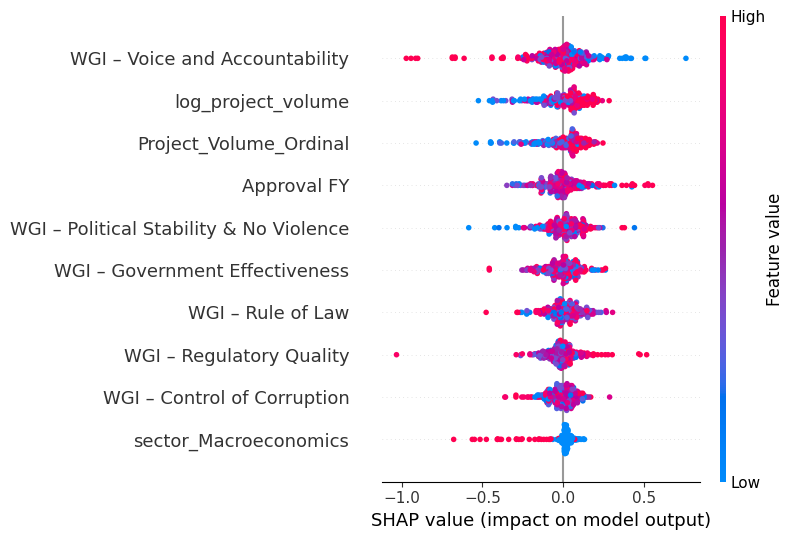

In [31]:
# ============================================
# SHAP Top 10 summary plot with long labels
# ============================================

import pandas as pd

# 1) Define long names (WGI only)
feature_long_names = {
    "wgi_cc": "WGI – Control of Corruption",
    "wgi_ge": "WGI – Government Effectiveness",
    "wgi_pv": "WGI – Political Stability & No Violence",
    "wgi_rl": "WGI – Rule of Law",
    "wgi_rq": "WGI – Regulatory Quality",
    "wgi_va": "WGI – Voice and Accountability",
}

# 2) Get full feature names (numeric + one-hot)
feature_names_raw = (
    numeric_features +
    list(
        preprocessor.named_transformers_["cat"]
        .get_feature_names_out(categorical_features)
    )
)

# 3) Apply human-readable names
feature_names_readable = [
    feature_long_names.get(f, f)
    for f in feature_names_raw
]

# 4) Convert shap values into DataFrame
shap_df = pd.DataFrame(shap_values, columns=feature_names_raw)

# 5) Find TOP 10 most influential features
top10_raw = (
    shap_df.abs().mean().sort_values(ascending=False).head(10).index.tolist()
)

top10_readable = [
    feature_long_names.get(f, f) for f in top10_raw
]

print("Top 10 important features:")
for raw, readable in zip(top10_raw, top10_readable):
    print(f"- {raw}  →  {readable}")

# 6) Extract SHAP values & X_sample columns for top10
top10_indices = [feature_names_raw.index(f) for f in top10_raw]
shap_top10 = shap_values[:, top10_indices]
X_top10 = pd.DataFrame(X_sample, columns=feature_names_raw)[top10_raw]

# 7) SHAP summary plot (dot)
shap.summary_plot(
    shap_top10,
    X_top10,
    feature_names=top10_readable,
    plot_type="dot"
)

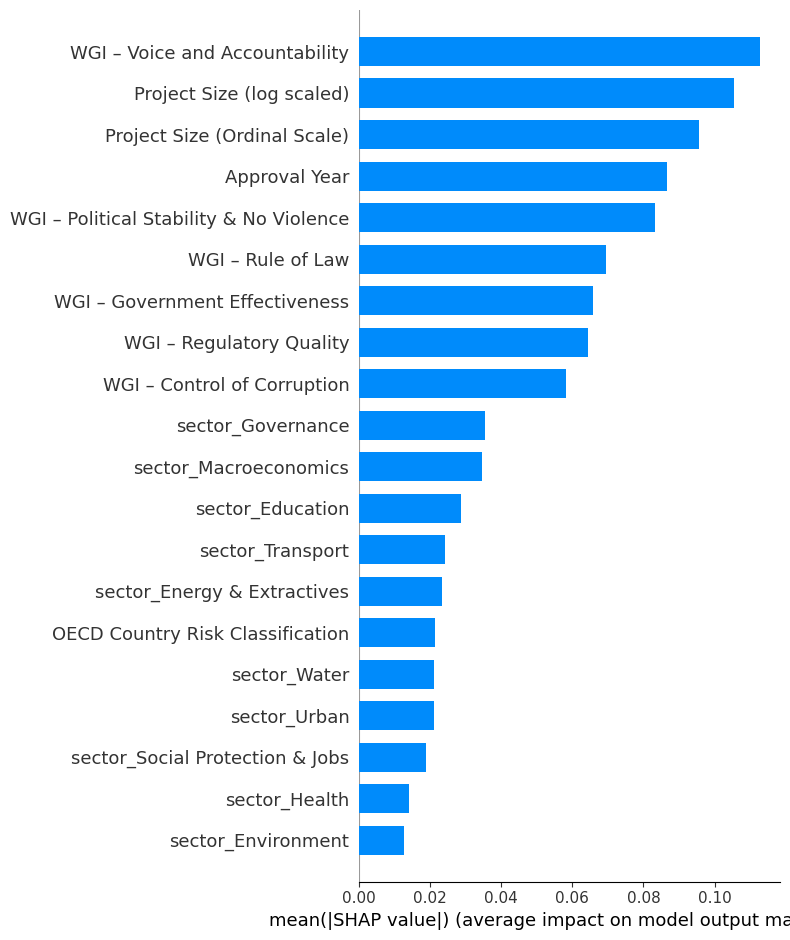

In [28]:
feature_long_names = {
    "wgi_cc": "WGI – Control of Corruption",
    "wgi_ge": "WGI – Government Effectiveness",
    "wgi_pv": "WGI – Political Stability & No Violence",
    "wgi_rl": "WGI – Rule of Law",
    "wgi_rq": "WGI – Regulatory Quality",
    "wgi_va": "WGI – Voice and Accountability",
    "Approval FY": "Approval Year",
    "CRC_Risk": "OECD Country Risk Classification",
    "log_project_volume": "Project Size (log scaled)",
    "Project_Volume_Ordinal": "Project Size (Ordinal Scale)",
}

# 기존 feature_names 가져오기
feature_names = (
    numeric_features +
    list(
        preprocessor.named_transformers_["cat"]
        .get_feature_names_out(categorical_features)
    )
)

feature_names_readable = [
    feature_long_names.get(f, f)   # 딕셔너리에 없으면 기존 이름 유지
    for f in feature_names
]

shap.summary_plot(
    shap_values,
    X_sample,
    feature_names=feature_names_readable,
    plot_type="bar"
)

In [ ]:
df.groupby("sector")["Outcome_Score"].mean().sort_values()

In [ ]:
df

In [ ]:
  # -----------------------------------------
# 1) Ex-ante WGI (Approval FY - 1년) 적용
# -----------------------------------------

proj_ex = projectDf_r.copy()

# 기본 정리
proj_ex["Country"] = proj_ex["Country"].astype(str).str.strip()
proj_ex["Approval FY"] = pd.to_numeric(proj_ex["Approval FY"], errors="coerce")

wgi_clean["Country"] = wgi_clean["Country"].astype(str).str.strip()
wgi_clean["year"] = pd.to_numeric(wgi_clean["year"], errors="coerce")

# WGI 사용할 연도 = 승인연도 - 1 (ex-ante)
proj_ex["WGI_year"] = proj_ex["Approval FY"] - 1

# WGI 병합
proj_ex = proj_ex.merge(
    wgi_clean,
    left_on=["Country", "WGI_year"],
    right_on=["Country", "year"],
    how="left"
).drop(columns=["year"])

proj_filtered_exante = proj_ex[proj_ex["Approval FY"] > 1995].copy()

proj = proj_filtered_exante.copy()

pv_map_ordinal = {
    "Less than 10 million": 1,
    ">=10 million & <25 million": 2,
    ">=25 million & <50 million": 3,
    ">=50 million & <100 million": 4,
    ">=100 million": 5,
}
proj["Project_Volume_Ordinal"] = proj["Project Volume"].map(pv_map_ordinal)

pv_map_midpoint = {
    "Less than 10 million": 5,
    ">=10 million & <25 million": 17.5,
    ">=25 million & <50 million": 37.5,
    ">=50 million & <100 million": 75,
    ">=100 million": 150,
}
proj["Project_Volume_MidpointM"] = proj["Project Volume"].map(pv_map_midpoint)
proj["log_project_volume"] = np.log1p(proj["Project_Volume_MidpointM"])

features = [
    "Approval FY",
    "CRC_Risk",
    "log_project_volume",
    "Project_Volume_Ordinal",
    "wgi_cc","wgi_ge","wgi_pv","wgi_rl","wgi_rq","wgi_va",
    "sector"
]

target = "Outcome_Score"

df = proj.dropna(subset=[target, "sector"] + features)

In [ ]:
numeric_features = [f for f in features if f != "sector"]
categorical_features = ["sector"]

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numeric_features),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
])

models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(random_state=42, n_estimators=300),
    "XGBoost": XGBRegressor(random_state=42, n_estimators=300, learning_rate=0.05, max_depth=4)
}

X = df[features]
y = df[target].astype(float)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

results = []
for name, model in models.items():
    pipe = Pipeline(steps=[("preprocessor", preprocessor), ("model", model)])
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)

    r2  = r2_score(y_test, pred)
    mae = mean_absolute_error(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))

    results.append({"Model": name, "R2": r2, "MAE": mae, "RMSE": rmse})
    print(f"{name:<20} | R²={r2:.3f} | MAE={mae:.3f} | RMSE={rmse:.3f}")

pd.DataFrame(results).sort_values("R2", ascending=False)